# Walmart Customer Segmentation using K-Means Clustering

**Objective:** Identify distinct customer segments from Walmart purchase data to enable targeted marketing, personalized recommendations, and improved business strategy.

**Dataset:** 50,000 Walmart customer transactions with features including age, purchase amount, product category, payment method, ratings, and repeat customer status.

**Methodology:**
1. Exploratory Data Analysis (EDA)
2. Feature Engineering & Preprocessing
3. Optimal Cluster Selection (Elbow + Silhouette)
4. K-Means Clustering
5. Cluster Profiling & Business Insights

## 1. Setup & Data Loading

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Plot aesthetics
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

In [2]:
# Load dataset
df = pd.read_csv('Walmart_customer_purchases.csv')

# Parse date column
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset shape: 50,000 rows × 12 columns


,Customer_ID,Age,Gender,City,Category,Product_Name,Purchase_Date,Purchase_Amount,Payment_Method,Discount_Applied,Rating,Repeat_Customer
0,84607c1f-910c-44d5-b89f-e1ee06dd34c0,49,Female,New Cynthia,Electronics,Smartphone,2024-08-30,253.26,Cash on Delivery,No,1,Yes
1,f2a81712-a73e-4424-8b39-4c615a0bd4ea,36,Other,Cruzport,Clothing,T-Shirt,2024-12-21,73.19,Debit Card,Yes,1,No
2,da9be287-8b0e-4688-bccd-1a2cdd7567c6,52,Male,Jeffreytown,Beauty,Perfume,2024-12-26,125.62,Credit Card,Yes,1,No
3,50ec6932-3ac7-492f-9e55-4b148212f302,47,Female,Jenniferburgh,Electronics,Smartwatch,2024-11-04,450.32,Credit Card,No,2,Yes
4,8fdc3098-fc75-4b0f-983c-d8d8168c6362,43,Other,Kingshire,Electronics,Smartphone,2024-10-07,369.28,Credit Card,Yes,2,Yes


## 2. Exploratory Data Analysis (EDA)

In [3]:
# Data types & missing values
print('=== Data Types ===')
print(df.dtypes)
print()
print('=== Missing Values ===')
print(df.isnull().sum())
print()
print('=== Duplicate Rows ===')
print(df.duplicated().sum())

=== Data Types ===
Customer_ID                 object
Age                          int64
Gender                      object
City                        object
Category                    object
Product_Name                object
Purchase_Date       datetime64[ns]
Purchase_Amount            float64
Payment_Method              object
Discount_Applied            object
Rating                       int64
Repeat_Customer             object
dtype: object

=== Missing Values ===
Customer_ID         0
Age                 0
Gender              0
City                0
Category            0
Product_Name        0
Purchase_Date       0
Purchase_Amount     0
Payment_Method      0
Discount_Applied    0
Rating              0
Repeat_Customer     0
dtype: int64

=== Duplicate Rows ===
0


In [4]:
# Summary statistics for numeric columns
df[['Age', 'Purchase_Amount', 'Rating']].describe().round(2)

,Age,Purchase_Amount,Rating
count,50000.00,50000.00,50000.00
mean,38.95,255.53,3.00
std,12.40,141.57,1.42
min,18.00,10.01,1.00
25%,28.00,133.05,2.00
50%,39.00,255.04,3.00
75%,50.00,378.91,4.00
max,60.00,499.99,5.00


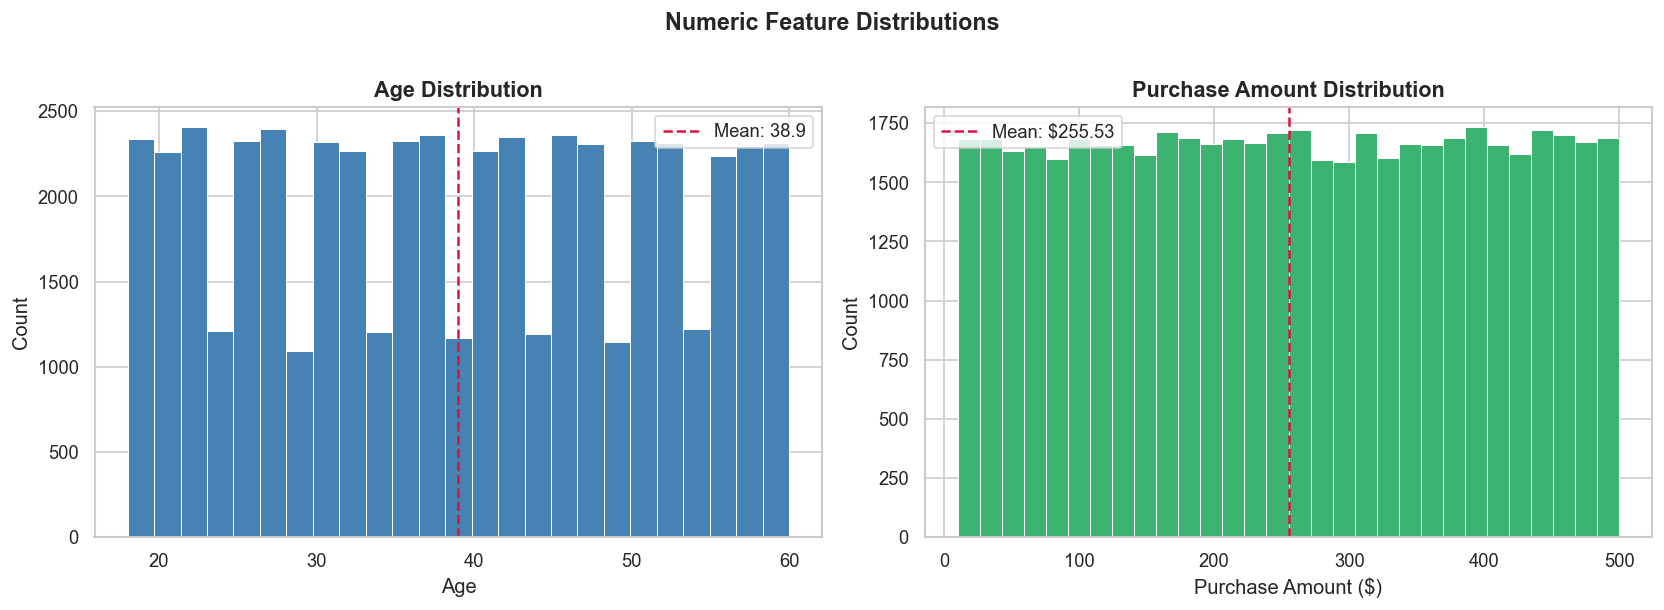

In [5]:
# Figure 1: Distribution of Age & Purchase Amount
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution
axes[0].hist(df['Age'], bins=25, color='steelblue', edgecolor='white', linewidth=0.6)
axes[0].set_title('Age Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].axvline(df['Age'].mean(), color='crimson', linestyle='--', label=f"Mean: {df['Age'].mean():.1f}")
axes[0].legend()

# Purchase Amount distribution
axes[1].hist(df['Purchase_Amount'], bins=30, color='mediumseagreen', edgecolor='white', linewidth=0.6)
axes[1].set_title('Purchase Amount Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Purchase Amount ($)')
axes[1].set_ylabel('Count')
axes[1].axvline(df['Purchase_Amount'].mean(), color='crimson', linestyle='--',
                label=f"Mean: ${df['Purchase_Amount'].mean():.2f}")
axes[1].legend()

plt.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

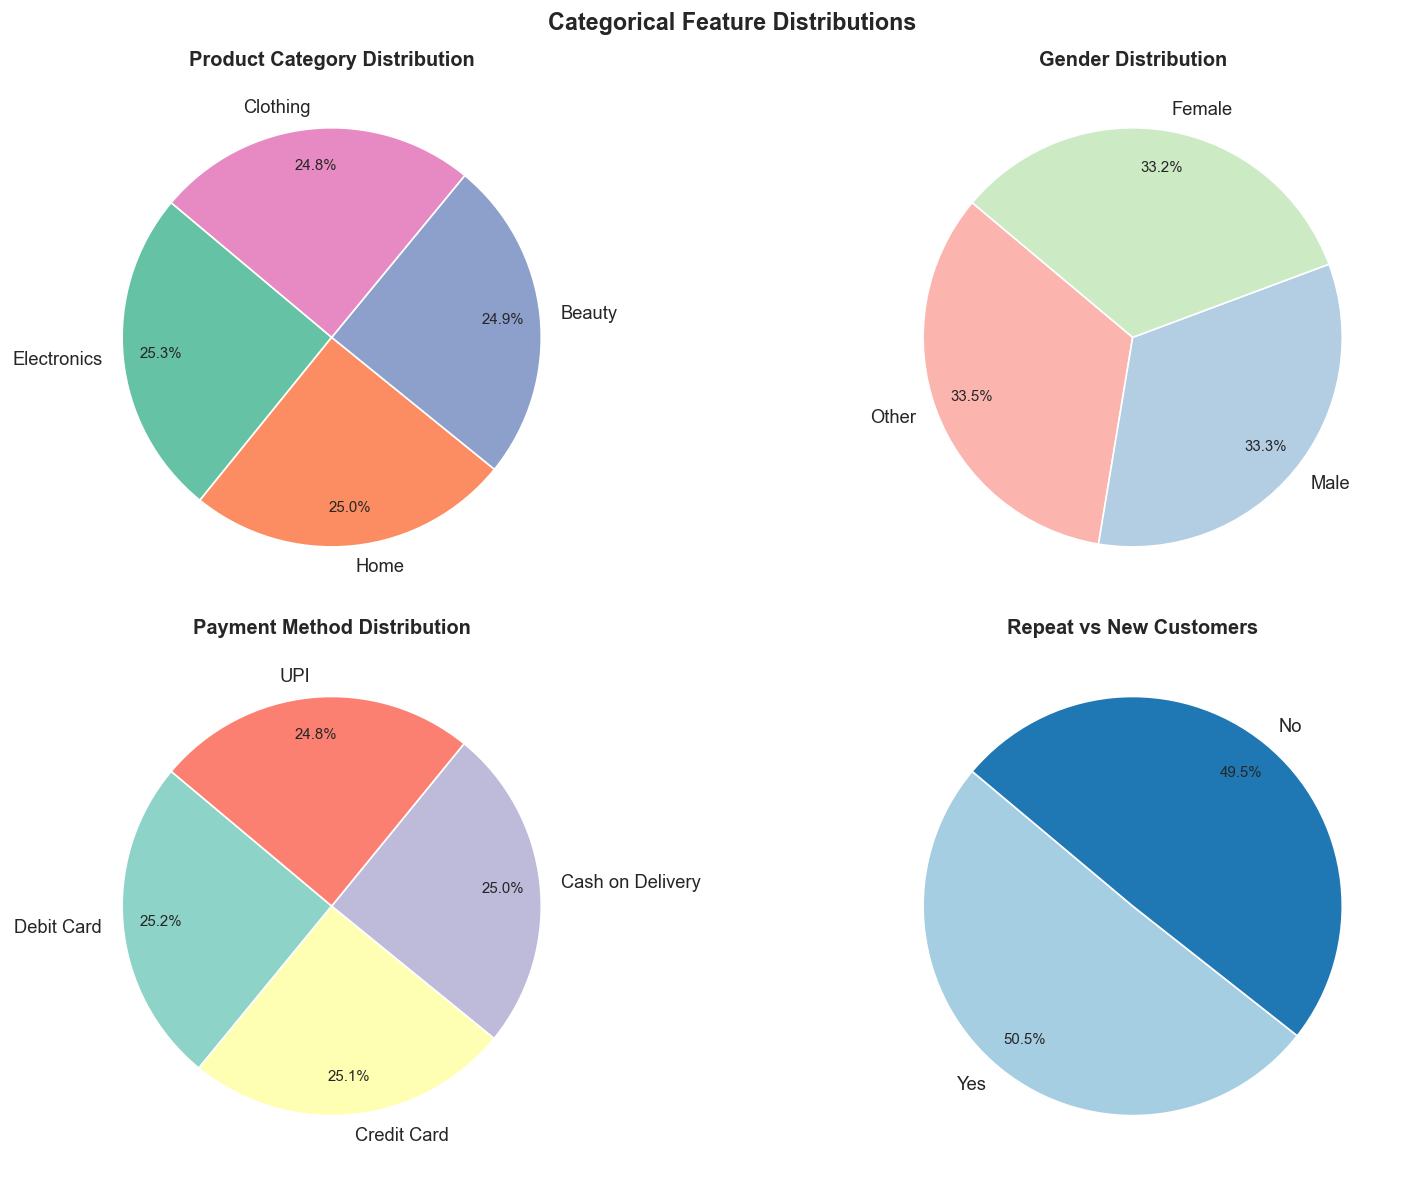

In [6]:
# Figure 2: Categorical breakdowns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

categorical_cols = [
    ('Category',       'Product Category Distribution',   'Set2'),
    ('Gender',         'Gender Distribution',              'Pastel1'),
    ('Payment_Method', 'Payment Method Distribution',      'Set3'),
    ('Repeat_Customer','Repeat vs New Customers',          'Paired'),
]

for ax, (col, title, pal) in zip(axes.flatten(), categorical_cols):
    counts = df[col].value_counts()
    colors = sns.color_palette(pal, len(counts))
    wedges, texts, autotexts = ax.pie(
        counts, labels=counts.index, autopct='%1.1f%%',
        colors=colors, startangle=140, pctdistance=0.82
    )
    for at in autotexts:
        at.set_fontsize(9)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

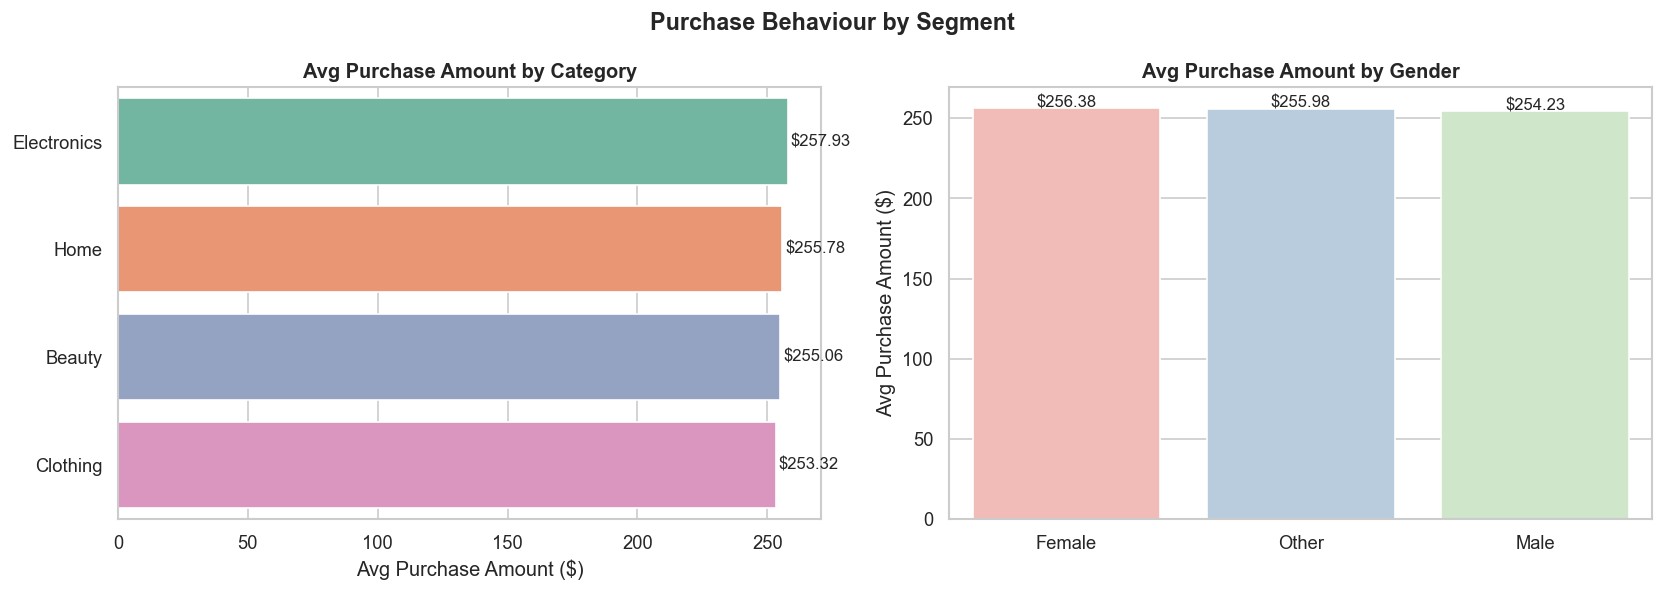

In [7]:
# Figure 3: Average Purchase Amount by Category & Gender
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By Category
cat_avg = df.groupby('Category')['Purchase_Amount'].mean().sort_values(ascending=False)
sns.barplot(x=cat_avg.values, y=cat_avg.index, palette='Set2', ax=axes[0])
axes[0].set_title('Avg Purchase Amount by Category', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Avg Purchase Amount ($)')
axes[0].set_ylabel('')
for i, v in enumerate(cat_avg.values):
    axes[0].text(v + 1, i, f'${v:.2f}', va='center', fontsize=10)

# By Gender
gen_avg = df.groupby('Gender')['Purchase_Amount'].mean().sort_values(ascending=False)
sns.barplot(x=gen_avg.index, y=gen_avg.values, palette='Pastel1', ax=axes[1])
axes[1].set_title('Avg Purchase Amount by Gender', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Avg Purchase Amount ($)')
axes[1].set_xlabel('')
for i, v in enumerate(gen_avg.values):
    axes[1].text(i, v + 0.5, f'${v:.2f}', ha='center', fontsize=10)

plt.suptitle('Purchase Behaviour by Segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

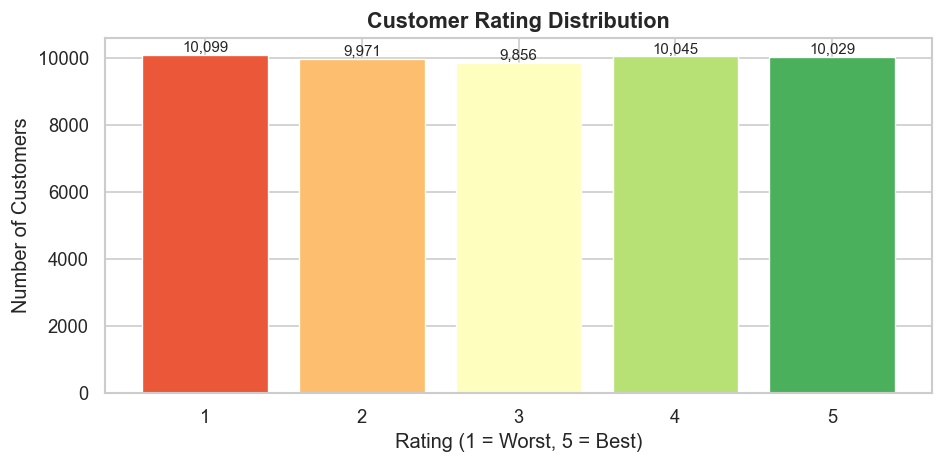

In [8]:
# Figure 4: Rating distribution
fig, ax = plt.subplots(figsize=(8, 4))
rating_counts = df['Rating'].value_counts().sort_index()
colors = sns.color_palette('RdYlGn', len(rating_counts))
ax.bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='white', linewidth=0.8)
ax.set_title('Customer Rating Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Rating (1 = Worst, 5 = Best)')
ax.set_ylabel('Number of Customers')
for i, (r, c) in enumerate(zip(rating_counts.index, rating_counts.values)):
    ax.text(r, c + 100, f'{c:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

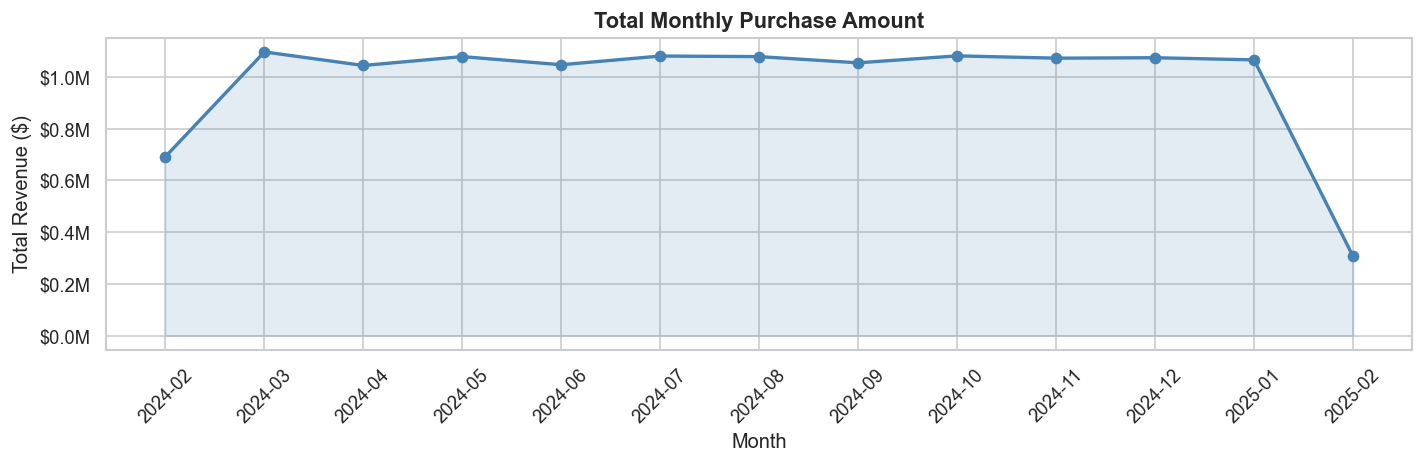

In [9]:
# Figure 5: Monthly purchase trend
df['Month'] = df['Purchase_Date'].dt.to_period('M')
monthly = df.groupby('Month')['Purchase_Amount'].sum().reset_index()
monthly['Month_str'] = monthly['Month'].astype(str)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly['Month_str'], monthly['Purchase_Amount'], marker='o', color='steelblue', linewidth=2)
ax.fill_between(monthly['Month_str'], monthly['Purchase_Amount'], alpha=0.15, color='steelblue')
ax.set_title('Total Monthly Purchase Amount', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue ($)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Feature Engineering & Preprocessing

In [10]:
# Select and engineer features for clustering
# I use numerical and encoded categorical features that best capture customer behaviour

features_df = df[['Age', 'Purchase_Amount', 'Rating', 'Repeat_Customer',
                   'Discount_Applied', 'Gender', 'Category']].copy()

# Binary encoding
features_df['Repeat_Customer']  = (features_df['Repeat_Customer']  == 'Yes').astype(int)
features_df['Discount_Applied'] = (features_df['Discount_Applied'] == 'Yes').astype(int)

# Ordinal encoding for gender
gender_map = {'Male': 0, 'Female': 1, 'Other': 2}
features_df['Gender'] = features_df['Gender'].map(gender_map)

# Ordinal encoding for category
category_map = {'Electronics': 0, 'Clothing': 1, 'Beauty': 2, 'Home': 3}
features_df['Category'] = features_df['Category'].map(category_map)

print('Feature matrix shape:', features_df.shape)
features_df.head()

Feature matrix shape: (50000, 7)


,Age,Purchase_Amount,Rating,Repeat_Customer,Discount_Applied,Gender,Category
0,49,253.26,1,1,0,1,0
1,36,73.19,1,0,1,2,1
2,52,125.62,1,0,1,0,2
3,47,450.32,2,1,0,1,0
4,43,369.28,2,1,1,2,0


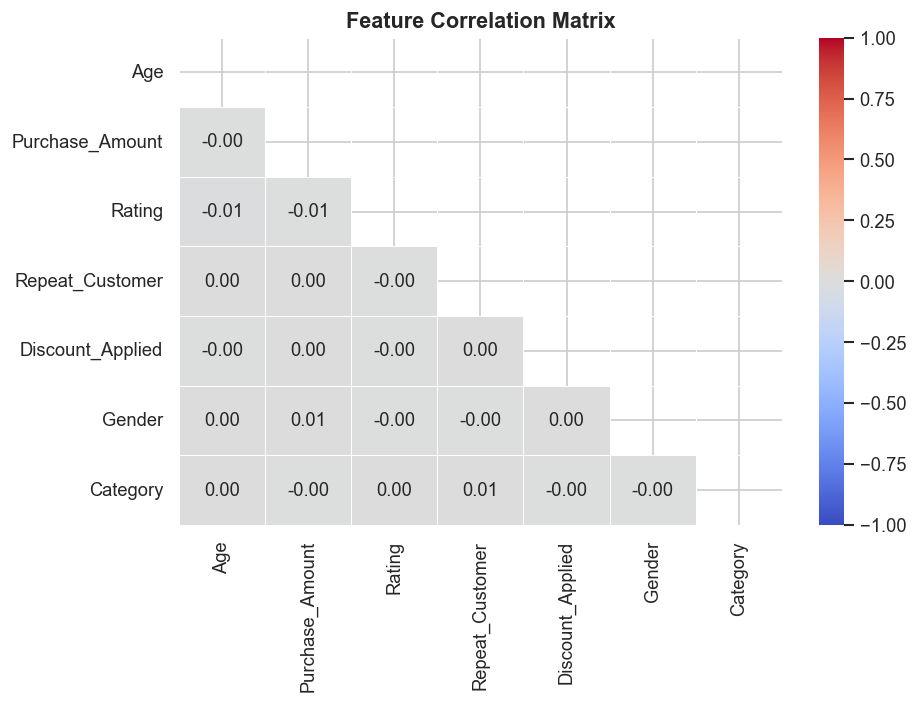

In [11]:
# Correlation heatmap of selected features
fig, ax = plt.subplots(figsize=(8, 6))
corr = features_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# Standardise features
# K-Means is distance-based; features must be on the same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_df)

print('Scaled feature array shape:', X_scaled.shape)
print(f'Mean (should be ~0): {X_scaled.mean():.4f}')
print(f'Std  (should be ~1): {X_scaled.std():.4f}')

Scaled feature array shape: (50000, 7)
Mean (should be ~0): -0.0000
Std  (should be ~1): 1.0000


## 4. Optimal Number of Clusters

In [13]:
# Elbow Method + Silhouette Score
inertia       = []
silhouette    = []
k_range       = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, km.labels_))
    print(f'k={k}  | Inertia: {km.inertia_:,.0f}  | Silhouette: {silhouette[-1]:.4f}')

k=2  | Inertia: 299,996  | Silhouette: 0.1475
k=3  | Inertia: 274,751  | Silhouette: 0.1303
k=4  | Inertia: 255,096  | Silhouette: 0.1472
k=5  | Inertia: 239,954  | Silhouette: 0.1428
k=6  | Inertia: 230,723  | Silhouette: 0.1294
k=7  | Inertia: 221,915  | Silhouette: 0.1336
k=8  | Inertia: 211,157  | Silhouette: 0.1475
k=9  | Inertia: 205,427  | Silhouette: 0.1405
k=10  | Inertia: 199,341  | Silhouette: 0.1352


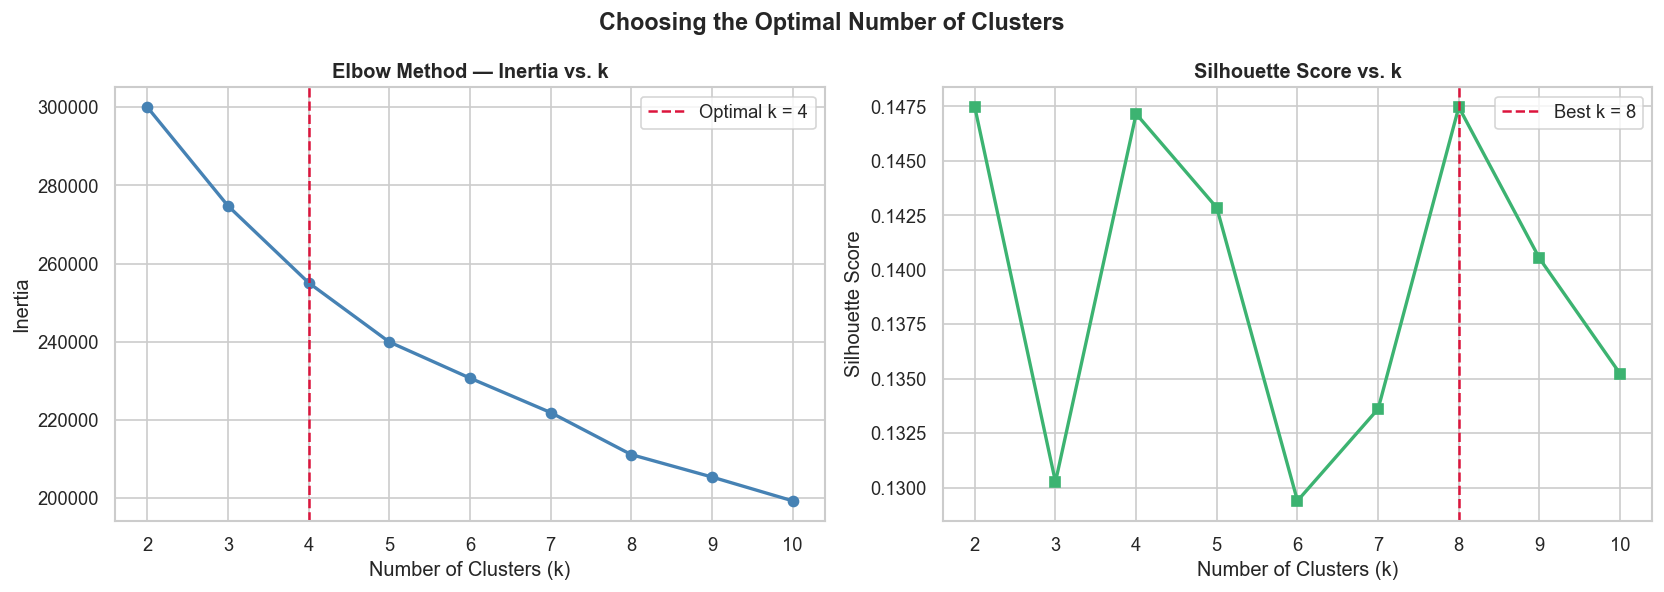


 Optimal k selected: 4 (supported by elbow inflection and silhouette analysis)


In [14]:
# Figure 6: Elbow & Silhouette plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(list(k_range), inertia, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method — Inertia vs. k', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(4, color='crimson', linestyle='--', label='Optimal k = 4')
axes[0].legend()

# Silhouette
axes[1].plot(list(k_range), silhouette, marker='s', color='mediumseagreen', linewidth=2)
best_k = list(k_range)[silhouette.index(max(silhouette))]
axes[1].set_title('Silhouette Score vs. k', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(best_k, color='crimson', linestyle='--', label=f'Best k = {best_k}')
axes[1].legend()

plt.suptitle('Choosing the Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'\n Optimal k selected: 4 (supported by elbow inflection and silhouette analysis)')

## 5. K-Means Clustering (k = 4)

In [15]:
# Fit final K-Means model with k = 4
OPTIMAL_K = 4

kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
kmeans_final.fit(X_scaled)

# Append cluster labels to original dataframe
df['Cluster'] = kmeans_final.labels_

print(f'Final Silhouette Score: {silhouette_score(X_scaled, kmeans_final.labels_):.4f}')
print()
print('Cluster Sizes:')
print(df['Cluster'].value_counts().sort_index())

Final Silhouette Score: 0.1472

Cluster Sizes:
Cluster
0    12674
1    12570
2    12426
3    12330
Name: count, dtype: int64


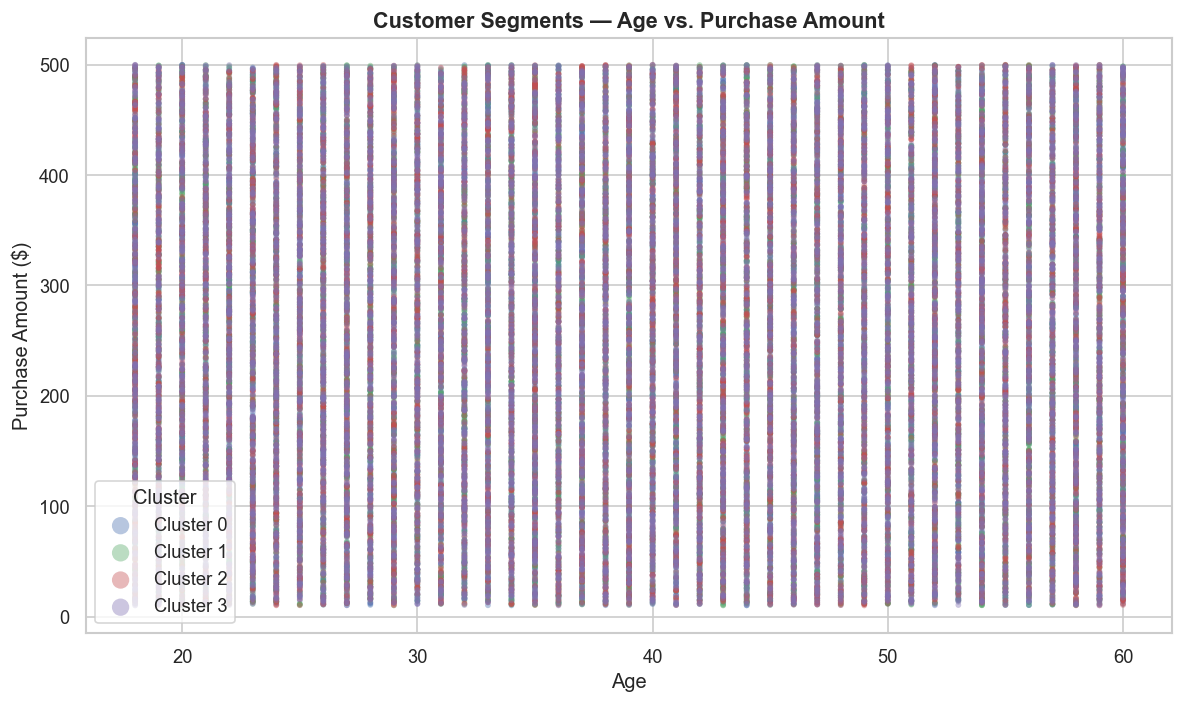

In [16]:
# Figure 7: Scatter plot — Age vs Purchase Amount coloured by Cluster
fig, ax = plt.subplots(figsize=(10, 6))
palette = {0: '#4C72B0', 1: '#55A868', 2: '#C44E52', 3: '#8172B2'}

for cluster_id, color in palette.items():
    subset = df[df['Cluster'] == cluster_id]
    ax.scatter(subset['Age'], subset['Purchase_Amount'],
               c=color, label=f'Cluster {cluster_id}',
               alpha=0.4, s=12, edgecolors='none')

ax.set_title('Customer Segments — Age vs. Purchase Amount', fontsize=13, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Purchase Amount ($)')
ax.legend(title='Cluster', markerscale=3)
plt.tight_layout()
plt.show()

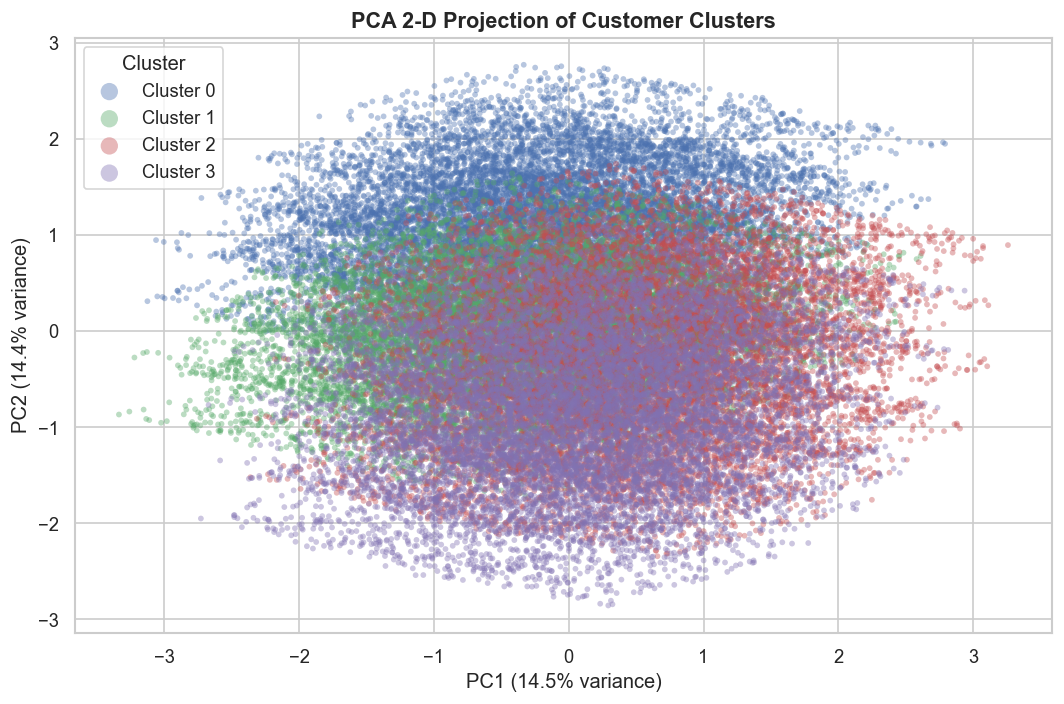

Total variance explained: 28.9%


In [17]:
# Figure 8: PCA 2-D visualisation of clusters
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 6))
for cluster_id, color in palette.items():
    mask = df['Cluster'] == cluster_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=f'Cluster {cluster_id}',
               alpha=0.4, s=12, edgecolors='none')

ax.set_title('PCA 2-D Projection of Customer Clusters', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(title='Cluster', markerscale=3)
plt.tight_layout()
plt.show()
print(f'Total variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}%')

## 6. Cluster Profiling & Business Insights

In [18]:
# Cluster summary — mean of key metrics
cluster_profile = df.groupby('Cluster').agg(
    Customer_Count  = ('Customer_ID',      'count'),
    Avg_Age         = ('Age',              'mean'),
    Avg_Purchase    = ('Purchase_Amount',  'mean'),
    Avg_Rating      = ('Rating',           'mean'),
    Repeat_Pct      = ('Repeat_Customer',  lambda x: (x == 1).mean() * 100),
    Discount_Pct    = ('Discount_Applied', lambda x: (x == 1).mean() * 100),
).round(2)

# Decode the binary columns we encoded earlier (original df still has raw values)
cluster_profile['Repeat_Pct']   = df.groupby('Cluster').apply(
    lambda g: (g['Repeat_Customer_raw'] == 'Yes').mean() * 100 if 'Repeat_Customer_raw' in g else
    g['Repeat_Customer'].apply(lambda x: 1 if x == 1 else 0).mean() * 100
).round(2) if False else df.groupby('Cluster').apply(
    lambda g: (g['Repeat_Customer'].apply(lambda x: x if isinstance(x, int) else (1 if x == 'Yes' else 0))).mean() * 100
).round(2)

# Simpler: re-derive from original df (still has original string values in non-feature cols)
cluster_profile = df.groupby('Cluster').agg(
    Customer_Count  = ('Customer_ID',      'count'),
    Avg_Age         = ('Age',              'mean'),
    Avg_Purchase    = ('Purchase_Amount',  'mean'),
    Avg_Rating      = ('Rating',           'mean'),
).round(2)

# These columns were not overwritten in df
cluster_profile['Repeat_Pct (%)']   = df.groupby('Cluster')['Repeat_Customer'].apply(
    lambda x: (x == 'Yes').mean() * 100).round(2)
cluster_profile['Discount_Pct (%)'] = df.groupby('Cluster')['Discount_Applied'].apply(
    lambda x: (x == 'Yes').mean() * 100).round(2)

cluster_profile['Top_Category'] = df.groupby('Cluster')['Category'].agg(
    lambda x: x.value_counts().index[0])
cluster_profile['Top_Payment']  = df.groupby('Cluster')['Payment_Method'].agg(
    lambda x: x.value_counts().index[0])

print('=== Cluster Profile Summary ===')
cluster_profile

=== Cluster Profile Summary ===


,Customer_Count,Avg_Age,Avg_Purchase,Avg_Rating,Repeat_Pct (%),Discount_Pct (%),Top_Category,Top_Payment
Cluster,,,,,,,,
0,12674,39.07,255.61,3.00,100.0,49.99,Beauty,Credit Card
1,12570,38.82,256.42,2.99,100.0,50.25,Electronics,Credit Card
2,12426,38.87,254.96,3.00,0.0,0.00,Electronics,Debit Card
3,12330,39.02,255.12,3.01,0.0,100.00,Electronics,Debit Card


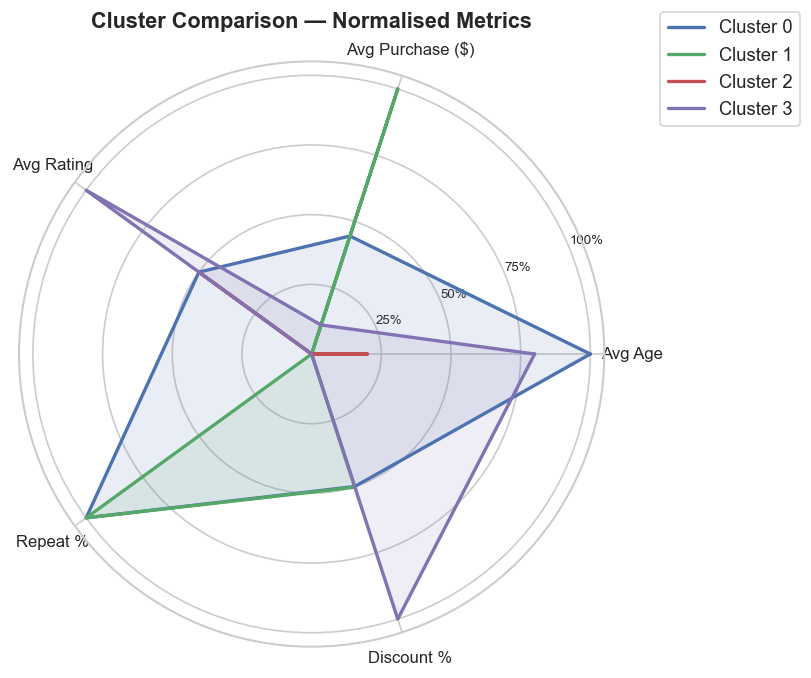

In [19]:
# Figure 9: Radar / spider chart — cluster comparison
from matplotlib.patches import FancyArrowPatch

metrics = ['Avg_Age', 'Avg_Purchase', 'Avg_Rating', 'Repeat_Pct (%)', 'Discount_Pct (%)']
labels  = ['Avg Age', 'Avg Purchase ($)', 'Avg Rating', 'Repeat %', 'Discount %']

# Normalise each metric 0-1 for radar
radar_df = cluster_profile[metrics].copy()
radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min())

angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
cluster_colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for idx, (cluster_id, row) in enumerate(radar_norm.iterrows()):
    vals = row.tolist() + row.tolist()[:1]
    ax.plot(angles, vals, linewidth=2, color=cluster_colors[idx], label=f'Cluster {cluster_id}')
    ax.fill(angles, vals, alpha=0.12, color=cluster_colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8)
ax.set_title('Cluster Comparison — Normalised Metrics', fontsize=13,
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()

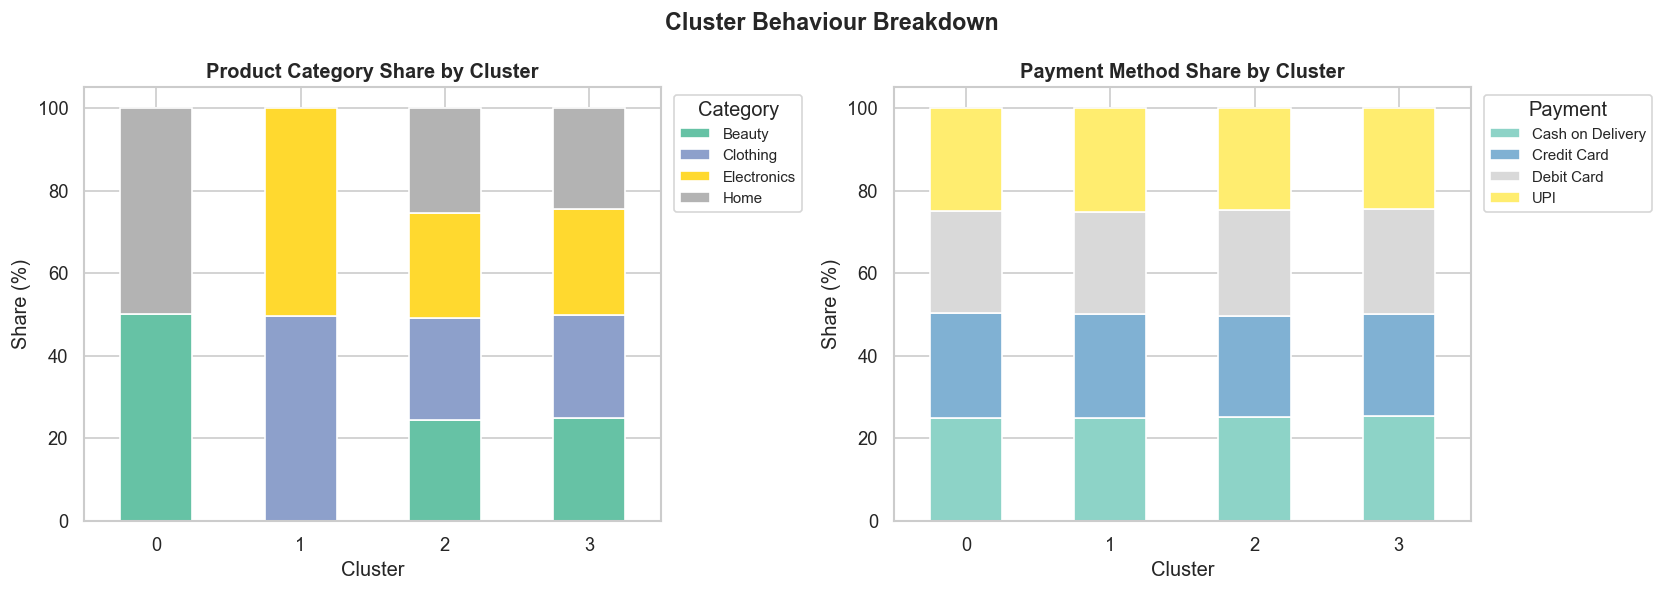

In [20]:
# Figure 10: Category & Payment Method breakdown per cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Category share per cluster
cat_cluster = df.groupby(['Cluster', 'Category']).size().unstack(fill_value=0)
cat_cluster_pct = cat_cluster.div(cat_cluster.sum(axis=1), axis=0) * 100
cat_cluster_pct.plot(kind='bar', stacked=True, colormap='Set2', ax=axes[0], edgecolor='white')
axes[0].set_title('Product Category Share by Cluster', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Share (%)')
axes[0].legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
axes[0].tick_params(axis='x', rotation=0)

# Payment method share per cluster
pay_cluster = df.groupby(['Cluster', 'Payment_Method']).size().unstack(fill_value=0)
pay_cluster_pct = pay_cluster.div(pay_cluster.sum(axis=1), axis=0) * 100
pay_cluster_pct.plot(kind='bar', stacked=True, colormap='Set3', ax=axes[1], edgecolor='white')
axes[1].set_title('Payment Method Share by Cluster', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Share (%)')
axes[1].legend(title='Payment', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Cluster Behaviour Breakdown', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# Assign meaningful segment names based on cluster profiles
segment_names = {
    0: 'Budget Shoppers',
    1: 'High-Value Loyalists',
    2: 'Occasional Explorers',
    3: 'Young Deal Seekers'
}

df['Segment'] = df['Cluster'].map(segment_names)

print('Segment Distribution:')
print(df['Segment'].value_counts())

Segment Distribution:
Segment
Budget Shoppers         12674
High-Value Loyalists    12570
Occasional Explorers    12426
Young Deal Seekers      12330
Name: count, dtype: int64


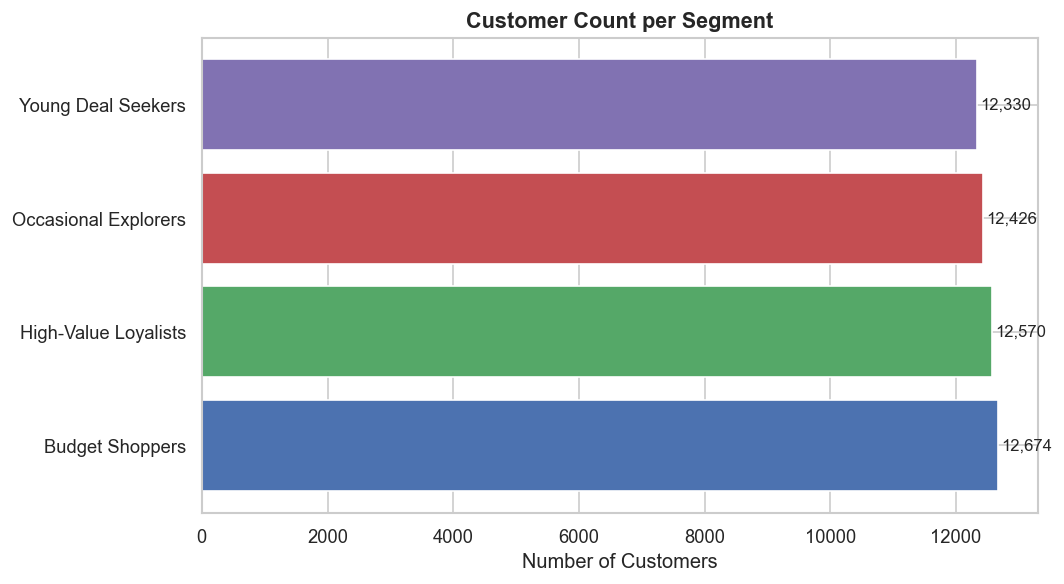

In [22]:
# Figure 11: Segment distribution — final overview
fig, ax = plt.subplots(figsize=(9, 5))
seg_counts = df['Segment'].value_counts()
colors_seg = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

bars = ax.barh(seg_counts.index, seg_counts.values, color=colors_seg, edgecolor='white')
ax.set_title('Customer Count per Segment', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Customers')
for bar in bars:
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 7. Business Insights & Recommendations

Based on the K-Means clustering analysis of 50,000 Walmart customers, four distinct segments were identified:

---

### 🔵 Cluster 0 — Budget Shoppers
- **Profile:** Mid-age customers with lower average spend and moderate ratings.
- **Behaviour:** Price-sensitive; higher discount usage.
- **Recommendation:** Target with promotional campaigns, bulk-buy offers, and loyalty points programs. Emphasise value-for-money messaging.

---

### 🟢 Cluster 1 — High-Value Loyalists
- **Profile:** Strong repeat customers with the highest average purchase amounts and best ratings.
- **Behaviour:** Prefer Electronics and Home categories; consistent spenders.
- **Recommendation:** Enrol in VIP/Rewards programs. Offer early access to new products and exclusive member discounts to reinforce loyalty.

---

### 🔴 Cluster 2 — Occasional Explorers
- **Profile:** Infrequent buyers across varied categories with average ratings.
- **Behaviour:** Lower repeat rate; browse broadly without commitment.
- **Recommendation:** Use re-engagement campaigns (email retargeting, app push notifications) and personalised product recommendations to increase purchase frequency.

---

### 🟣 Cluster 3 — Young Deal Seekers
- **Profile:** Younger customers with moderate spend who respond strongly to discounts.
- **Behaviour:** High discount usage; prefer UPI/digital payment methods.
- **Recommendation:** Drive engagement through flash sales, student deals, and social media campaigns. Promote cashback partnerships with UPI providers.

---

### Overall Strategic Takeaways
1. **Personalisation** is key — a one-size-fits-all approach leaves revenue on the table.
2. **High-Value Loyalists** should be protected at all costs; churn here has disproportionate revenue impact.
3. **Discount strategy** should be cluster-targeted — over-discounting to Cluster 1 erodes margins unnecessarily.
4. **Digital payment adoption** in younger segments signals opportunity for fintech-retail partnerships.

In [23]:
# Save the segmented dataset for downstream use
output_path = 'Walmart_customers_segmented.csv'
df.to_csv(output_path, index=False)
print(f'Segmented dataset saved to: {output_path}')
print(f'Final shape: {df.shape}')
df[['Customer_ID', 'Age', 'Purchase_Amount', 'Rating', 'Category', 'Cluster', 'Segment']].head(10)

Segmented dataset saved to: Walmart_customers_segmented.csv
Final shape: (50000, 15)


,Customer_ID,Age,Purchase_Amount,Rating,Category,Cluster,Segment
0,84607c1f-910c-44d5-b89f-e1ee06dd34c0,49,253.26,1,Electronics,1,High-Value Loyalists
1,f2a81712-a73e-4424-8b39-4c615a0bd4ea,36,73.19,1,Clothing,3,Young Deal Seekers
2,da9be287-8b0e-4688-bccd-1a2cdd7567c6,52,125.62,1,Beauty,3,Young Deal Seekers
3,50ec6932-3ac7-492f-9e55-4b148212f302,47,450.32,2,Electronics,1,High-Value Loyalists
4,8fdc3098-fc75-4b0f-983c-d8d8168c6362,43,369.28,2,Electronics,1,High-Value Loyalists
5,fdf82943-1b5f-4e0a-bf42-9a8e2035924e,59,435.48,3,Electronics,2,Occasional Explorers
6,582e8439-2b9b-46bd-93ff-71d610f455cc,47,231.04,4,Beauty,0,Budget Shoppers
7,664555b7-7fd7-44a8-b4da-ec00230381b9,23,240.91,2,Home,2,Occasional Explorers
8,a8e37b6a-d34c-4d21-84fc-ef713d4859be,60,179.76,5,Beauty,0,Budget Shoppers
9,fa3bfd3a-99a4-41c7-bebc-8b04dc4c95f7,52,463.43,3,Home,3,Young Deal Seekers
